<a href="https://colab.research.google.com/github/Harsha-1622/Innolift-Internship-Daily-Tasks/blob/main/M2_model_development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Imports**

In [14]:
# ==========================================
# IMPORTS
# ==========================================
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt


from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

### **Create Folders**

In [2]:
# ==========================================
# CREATE FOLDERS
# ==========================================

os.makedirs("models", exist_ok=True)
os.makedirs("charts", exist_ok=True)

### **Load Dataset**

In [3]:
# ==========================================
# LOAD DATASET
# ==========================================

print("Loading Dataset...\n")

df = pd.read_csv(
    "household_power_consumption.csv",
    low_memory=False
)

print("Original Dataset Shape:")
print(df.shape)


(1048575, 9)


### **Data Cleaning**

In [4]:
# ==========================================
# DATA CLEANING
# ==========================================

df.replace(
    '?',
    np.nan,
    inplace=True
)

numeric_columns = [

    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

for col in numeric_columns:

    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

for col in numeric_columns:

    df[col] = df[col].fillna(
        df[col].mean()
    )

df = df.sample(
    n=50000,
    random_state=42
)

print(
    "\nData Cleaning Completed!"
)

print(
    "Dataset Shape:",
    df.shape
)

(50000, 9)


### **Feature Selection**

In [15]:
# ==========================================
# FEATURE SELECTION
# ==========================================

X = df[
    [
        'Global_reactive_power',
        'Voltage',
        'Global_intensity',
        'Sub_metering_1',
        'Sub_metering_2',
        'Sub_metering_3'
    ]
]

y = df[
    'Global_active_power'
]

print(
    "\nFeature Selection Completed!"
)

print(
    "Features Shape:",
    X.shape
)

print(
    "Target Shape:",
    y.shape
)



Feature Selection Completed!
Features Shape: (50000, 6)
Target Shape: (50000,)


### **Train Test Split**

In [16]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

print(
    "\nTrain-Test Split Completed!"
)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test :",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test :",
    y_test.shape
)


Train-Test Split Completed!
X_train: (40000, 6)
X_test : (10000, 6)
y_train: (40000,)
y_test : (10000,)


### **Baseline Model**

In [17]:
# ==========================================
# BASELINE MODEL
# ==========================================

print(
    "\nTraining Random Forest Baseline Model..."
)

baseline_model = RandomForestRegressor(

    n_estimators=100,

    random_state=42,

    n_jobs=-1
)

baseline_model.fit(

    X_train,

    y_train
)

print(
    "Baseline Model Trained!"
)



Training Random Forest Baseline Model...
Baseline Model Trained!


### **Baseline Evaluation**

In [18]:
# ==========================================
# BASELINE EVALUATION
# ==========================================

baseline_predictions = baseline_model.predict(

    X_test
)

baseline_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(

    y_test,

    baseline_predictions
)

baseline_r2 = r2_score(

    y_test,

    baseline_predictions
)

print(
    "\n========== BASELINE MODEL ==========\n"
)

print(
    "RMSE :",
    round(baseline_rmse, 4)
)

print(
    "MAE  :",
    round(baseline_mae, 4)
)

print(
    "R²   :",
    round(baseline_r2, 4)
)


========== BASELINE MODEL ==========

RMSE : 0.0392
MAE  : 0.021
R²   : 0.9988


### **Gradient Boosting Regressor**

In [19]:
# ==========================================
# GRADIENT BOOSTING REGRESSOR
# ==========================================

print(
    "\nTraining Gradient Boosting Regressor..."
)

gbr_model = GradientBoostingRegressor(

    random_state=42
)

gbr_model.fit(

    X_train,

    y_train
)

print(
    "Gradient Boosting Model Trained!"
)



Training Gradient Boosting Regressor...
Gradient Boosting Model Trained!


### **Cross Validation**

In [20]:
# ==========================================
# CROSS VALIDATION
# ==========================================

print(
    "\nRunning Cross Validation..."
)

cv_scores = cross_val_score(

    gbr_model,

    X_train,

    y_train,

    cv=5,

    scoring='neg_mean_squared_error'
)

cv_rmse = np.sqrt(

    -cv_scores
)

print(
    "\n========== CROSS VALIDATION ==========\n"
)

print(
    "Mean RMSE:",
    round(
        cv_rmse.mean(),
        4
    )
)

print(
    "Standard Deviation:",
    round(
        cv_rmse.std(),
        4
    )
)


Running Cross Validation...

========== CROSS VALIDATION ==========

Mean RMSE: 0.0352
Standard Deviation: 0.0013


### **Hyperparameter Tuning**

In [21]:
# ==========================================
# HYPERPARAMETER TUNING
# ==========================================

print(
    "\nStarting Grid Search..."
)

param_grid = {

    'n_estimators': [
        50,
        100,
        150
    ],

    'max_depth': [
        3,
        5,
        7
    ],

    'min_samples_split': [
        2,
        5,
        10
    ]
}

grid = GridSearchCV(

    estimator=
    GradientBoostingRegressor(
        random_state=42
    ),

    param_grid=
    param_grid,

    cv=5,

    scoring=
    'neg_mean_squared_error',

    n_jobs=-1
)

grid.fit(

    X_train,

    y_train
)

print(
    "\n========== GRID SEARCH RESULTS ==========\n"
)

print(
    "Best Parameters:"
)

print(
    grid.best_params_
)

print(
    "\nBest Score:"
)

print(
    grid.best_score_
)


Starting Grid Search...

========== GRID SEARCH RESULTS ==========

Best Parameters:
{'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 150}

Best Score:
-0.0010781787361170696


### **Validation Curve**

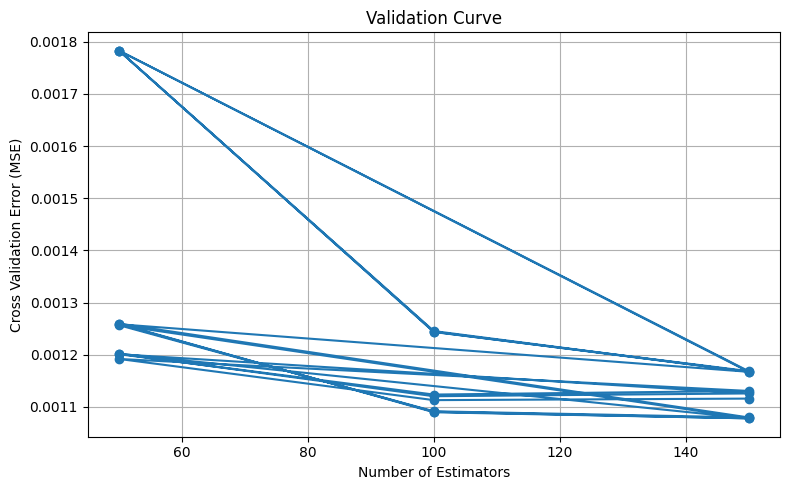


validation_curve.png saved!


In [22]:
# ==========================================
# VALIDATION CURVE
# ==========================================

results = pd.DataFrame(
    grid.cv_results_
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(

    results[
        'param_n_estimators'
    ],

    -results[
        'mean_test_score'
    ],

    marker='o'
)

plt.title(
    "Validation Curve"
)

plt.xlabel(
    "Number of Estimators"
)

plt.ylabel(
    "Cross Validation Error (MSE)"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/validation_curve.png"
)

plt.show()

print(
    "\nvalidation_curve.png saved!"
)

### **Randomized Search**

In [23]:
# ==========================================
# RANDOMIZED SEARCH CV
# ==========================================

print(
    "\nStarting RandomizedSearchCV..."
)

random_search = RandomizedSearchCV(

    estimator=
    GradientBoostingRegressor(
        random_state=42
    ),

    param_distributions=
    param_grid,

    n_iter=10,

    cv=5,

    scoring=
    'neg_mean_squared_error',

    random_state=42,

    n_jobs=-1
)

random_search.fit(

    X_train,

    y_train
)

print(
    "\n========== RANDOMIZED SEARCH RESULTS ==========\n"
)

print(
    "Best Parameters:"
)

print(
    random_search.best_params_
)

print(
    "\nBest Score:"
)

print(
    random_search.best_score_
)


Starting RandomizedSearchCV...

========== RANDOMIZED SEARCH RESULTS ==========

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'max_depth': 5}

Best Score:
-0.0010781787361170696


### **Select Best Model**

In [24]:
# ==========================================
# SELECT BEST MODEL
# ==========================================

grid_rmse = np.sqrt(
    -grid.best_score_
)

random_rmse = np.sqrt(
    -random_search.best_score_
)

if grid_rmse <= random_rmse:

    tuned_model = grid.best_estimator_

    best_method = "GridSearchCV"

else:

    tuned_model = random_search.best_estimator_

    best_method = "RandomizedSearchCV"

print(
    "\nBest Search Method:",
    best_method
)



Best Search Method: GridSearchCV


### **Tuned Model Evaluation**

In [25]:
# ==========================================
# TUNED MODEL EVALUATION
# ==========================================

tuned_predictions = tuned_model.predict(
    X_test
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print(
    "\n========== TUNED MODEL ==========\n"
)

print(
    "RMSE :",
    round(tuned_rmse, 4)
)

print(
    "MAE  :",
    round(tuned_mae, 4)
)

print(
    "R²   :",
    round(tuned_r2, 4)
)


========== TUNED MODEL ==========

RMSE : 0.0345
MAE  : 0.0195
R²   : 0.9991


### **Comparison Table**

In [26]:
# ==========================================
# COMPARISON TABLE
# ==========================================

comparison = pd.DataFrame({

    "Model": [

        "Random Forest",

        "Gradient Boosting"
    ],

    "RMSE": [

        baseline_rmse,

        tuned_rmse
    ],

    "MAE": [

        baseline_mae,

        tuned_mae
    ],

    "R2 Score": [

        baseline_r2,

        tuned_r2
    ]
})

print(
    "\n========== COMPARISON TABLE ==========\n"
)

print(
    comparison
)

comparison.to_csv(

    "comparison.csv",

    index=False
)

print(
    "\ncomparison.csv saved!"
)


========== COMPARISON TABLE ==========

               Model      RMSE       MAE  R2 Score
0      Random Forest  0.039163  0.020980  0.998806
1  Gradient Boosting  0.034506  0.019531  0.999073

comparison.csv saved!


### **Actual Vs Predicted Plot**

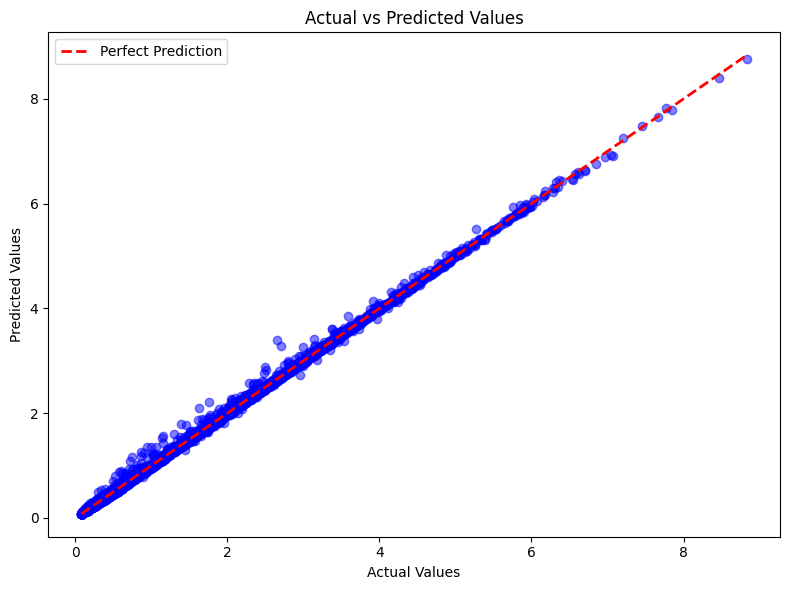

In [27]:
# ==========================================
# ACTUAL VS PREDICTED PLOT
# ==========================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    y_test,

    tuned_predictions,

    alpha=0.5,

    color='blue'
)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color='red',

    linestyle='--',

    linewidth=2,

    label='Perfect Prediction'
)

plt.title(
    "Actual vs Predicted Values"
)

plt.xlabel(
    "Actual Values"
)

plt.ylabel(
    "Predicted Values"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/actual_vs_predicted.png"
)

plt.show()

### **Residual Plot**

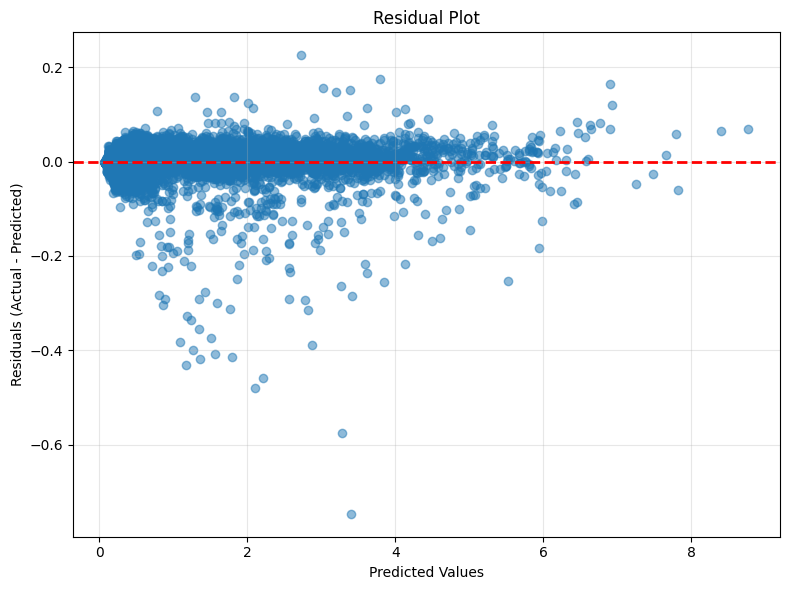


residual_plot.png saved!


In [28]:
# ==========================================
# RESIDUAL PLOT
# ==========================================

residuals = y_test - tuned_predictions

plt.figure(
    figsize=(8, 6)
)

plt.scatter(

    tuned_predictions,

    residuals,

    alpha=0.5
)

plt.axhline(

    y=0,

    color='red',

    linestyle='--',

    linewidth=2
)

plt.title(
    "Residual Plot"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals (Actual - Predicted)"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "charts/residual_plot.png"
)

plt.show()

print(
    "\nresidual_plot.png saved!"
)

### **Feature Importance Plot**


========== FEATURE IMPORTANCE ==========

                 Feature  Importance
2       Global_intensity    0.999102
1                Voltage    0.000278
0  Global_reactive_power    0.000238
3         Sub_metering_1    0.000214
5         Sub_metering_3    0.000104
4         Sub_metering_2    0.000064


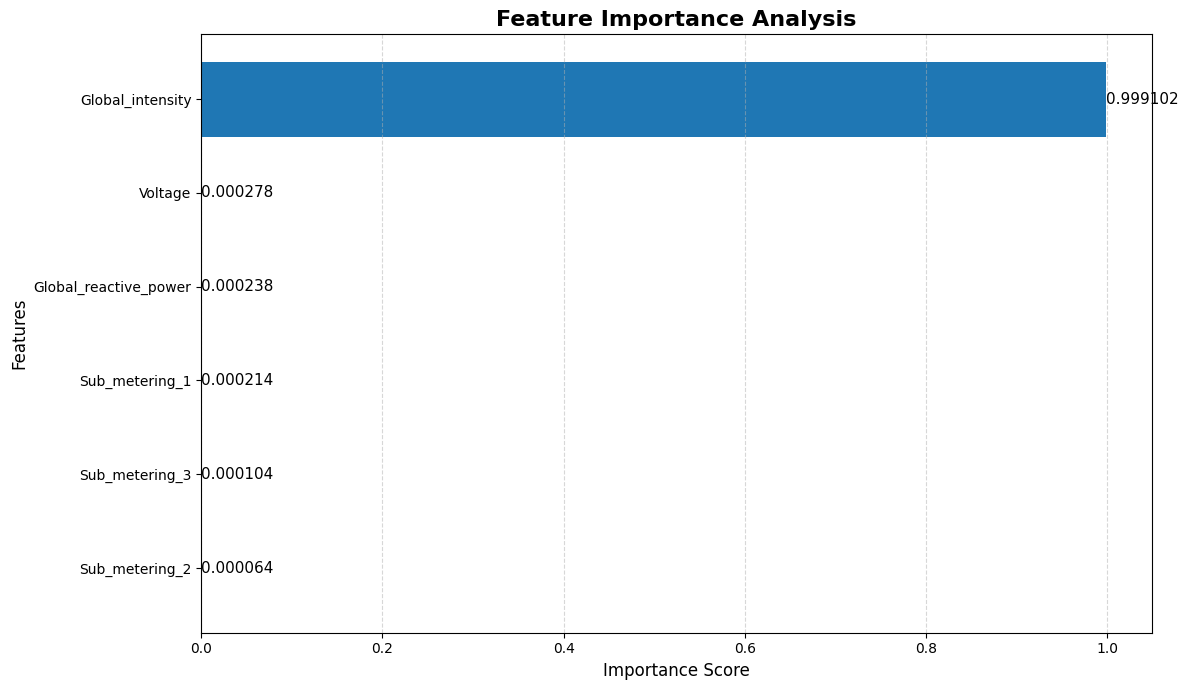


feature_importance.png saved!


In [29]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": tuned_model.feature_importances_
})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False
)

print(
    "\n========== FEATURE IMPORTANCE ==========\n"
)

print(importance_df)

plt.figure(
    figsize=(12, 7)
)

bars = plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]
)

plt.title(
    "Feature Importance Analysis",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    "Importance Score",
    fontsize=12
)

plt.ylabel(
    "Features",
    fontsize=12
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.gca().invert_yaxis()

for bar in bars:

    width = bar.get_width()

    plt.text(

        width,

        bar.get_y() + bar.get_height()/2,

        f"{width:.6f}",

        va='center',

        ha='left',

        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    "charts/feature_importance.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print(
    "\nfeature_importance.png saved!"
)

### **Save Final Model**

In [30]:
# ==========================================
# SAVE FINAL MODEL
# ==========================================

joblib.dump(

    tuned_model,

    "models/final_model.pkl"
)

print(
    "\nfinal_model.pkl saved!"
)


final_model.pkl saved!


### **Predict Function**

In [ ]:
# ==========================================
# PREDICT FUNCTION
# ==========================================

def predict(inputs):

    try:

        if (
            inputs["Voltage"] <= 0
            or inputs["Global_intensity"] < 0
            or inputs["Global_reactive_power"] < 0
        ):

            return {

                "prediction": "ERROR",

                "category": "Invalid Input",

                "advice": "Invalid input values"
            }

        input_df = pd.DataFrame(
            [inputs]
        )

        prediction = float(
            tuned_model.predict(
                input_df
            )[0]
        )

        if prediction < 1:

            category = "Low Consumption"

            advice = "Power usage is low."

        elif prediction < 3:

            category = "Moderate Consumption"

            advice = (
                "Power usage is within normal range."
            )

        else:

            category = "High Consumption"

            advice = (
                "Power usage is high. Consider saving energy."
            )

        return {

            "prediction":
            round(prediction, 3),

            "category":
            category,

            "advice":
            advice
        }

    except Exception as e:

        return {

            "prediction": "ERROR",

            "category": "Exception",

            "advice": str(e)
        }


### **Predict Function**

In [34]:
# ==========================================
# PREDICT FUNCTION
# ==========================================

def predict(inputs):

    if (
        inputs["Voltage"] <= 0
        or inputs["Global_intensity"] < 0
        or inputs["Global_reactive_power"] < 0
    ):

        return {

            "prediction": "ERROR",

            "category": "Invalid Input",

            "advice": "Invalid input values"
        }

    input_df = pd.DataFrame(
        [inputs]
    )

    prediction = float(
        tuned_model.predict(
            input_df
        )[0]
    )

    if prediction < 1:

        category = "Low Consumption"

        advice = "Power usage is low."

    elif prediction < 3:

        category = "Moderate Consumption"

        advice = "Power usage is within normal range."

    else:

        category = "High Consumption"

        advice = (
            "Power usage is high. Consider saving energy."
        )

    return {

        "prediction":
        round(prediction, 3),

        "category":
        category,

        "advice":
        advice
    }

### **10 Test Cases**

In [35]:
# ==========================================
# 10 TEST CASES
# ==========================================

def enrich_power(prediction):

    if prediction < 1:

        category = "Low Consumption"

        advice = "Power usage is low."

    elif prediction < 3:

        category = "Moderate Consumption"

        advice = "Power usage is within normal range."

    else:

        category = "High Consumption"

        advice = (
            "Power usage is high. Consider saving energy."
        )

    return category, advice


test_cases = [

{
    "Global_reactive_power":0.01,
    "Voltage":240,
    "Global_intensity":1,
    "Sub_metering_1":0,
    "Sub_metering_2":0,
    "Sub_metering_3":1
},

{
    "Global_reactive_power":0.05,
    "Voltage":238,
    "Global_intensity":3,
    "Sub_metering_1":0,
    "Sub_metering_2":1,
    "Sub_metering_3":5
},

{
    "Global_reactive_power":0.10,
    "Voltage":240,
    "Global_intensity":5,
    "Sub_metering_1":0,
    "Sub_metering_2":1,
    "Sub_metering_3":10
},

{
    "Global_reactive_power":0.15,
    "Voltage":236,
    "Global_intensity":8,
    "Sub_metering_1":1,
    "Sub_metering_2":2,
    "Sub_metering_3":15
},

{
    "Global_reactive_power":0.20,
    "Voltage":235,
    "Global_intensity":10,
    "Sub_metering_1":2,
    "Sub_metering_2":1,
    "Sub_metering_3":20
},

{
    "Global_reactive_power":0.25,
    "Voltage":232,
    "Global_intensity":12,
    "Sub_metering_1":3,
    "Sub_metering_2":2,
    "Sub_metering_3":25
},

{
    "Global_reactive_power":0.30,
    "Voltage":230,
    "Global_intensity":15,
    "Sub_metering_1":4,
    "Sub_metering_2":3,
    "Sub_metering_3":30
},

{
    "Global_reactive_power":0.40,
    "Voltage":225,
    "Global_intensity":20,
    "Sub_metering_1":7,
    "Sub_metering_2":5,
    "Sub_metering_3":40
},

{
    "Global_reactive_power":0.45,
    "Voltage":223,
    "Global_intensity":22,
    "Sub_metering_1":8,
    "Sub_metering_2":6,
    "Sub_metering_3":45
},

# Invalid test case
{
    "Global_reactive_power":-1,
    "Voltage":0,
    "Global_intensity":-5,
    "Sub_metering_1":-2,
    "Sub_metering_2":-1,
    "Sub_metering_3":-10
}

]

results = []

print(
    "\n========== 10 TEST CASES ==========\n"
)

for i, sample in enumerate(
    test_cases,
    start=1
):

    result = predict(
        sample
    )

    results.append({

        "Sample": i,

        "Predicted Power":
        result["prediction"],

        "Category":
        result["category"],

        "Advice":
        result["advice"]
    })
results_df = pd.DataFrame(
    results
)

print(
    results_df.to_string(
        index=False
    )
)

results_df.to_csv(

    "test_cases_results.csv",

    index=False
)

print(
    "\ntest_cases_results.csv saved!"
)


========== 10 TEST CASES ==========

 Sample Predicted Power             Category                                       Advice
      1           0.231      Low Consumption                          Power usage is low.
      2           0.652      Low Consumption                          Power usage is low.
      3           1.163 Moderate Consumption          Power usage is within normal range.
      4            1.88 Moderate Consumption          Power usage is within normal range.
      5           2.354 Moderate Consumption          Power usage is within normal range.
      6           2.711 Moderate Consumption          Power usage is within normal range.
      7            3.44     High Consumption Power usage is high. Consider saving energy.
      8           4.397     High Consumption Power usage is high. Consider saving energy.
      9           4.859     High Consumption Power usage is high. Consider saving energy.
     10           ERROR        Invalid Input                  

### **Final Result**

In [36]:
# ==========================================
# FINAL RESULT
# ==========================================

print(
    "\n========== FINAL RESULT ==========\n"
)

print(
    "Best Model : Gradient Boosting Regressor"
)

print(
    "RMSE :",
    round(tuned_rmse, 4)
)

print(
    "MAE :",
    round(tuned_mae, 4)
)

print(
    "R² Score :",
    round(tuned_r2, 4)
)


========== FINAL RESULT ==========

Best Model : Gradient Boosting Regressor
RMSE : 0.0345
MAE : 0.0195
R² Score : 0.9991
